<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Curso: Visualización para la Analítica de Datos</p>

<p style="text-align: center;"> Grupo: 01 </p>

<p style="text-align: center;"> Tarea 02 - Componente práctico del Curso</p>

<p style="text-align: center;">  Estudiante: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellín, Septiembre 2026</p>

In [27]:
import importlib
import subprocess
import sys

librerias_proyecto = {"numpy": "numpy",
             "pandas": "pandas",
             "matplotlib":"matplotlib",
             "seaborn":"seaborn",
             "openpyxl": "openpyxl",
             "geopandas": "geopandas",
             "folium": "folium",
             "shapely": "shapely",
             "requests": "requests"
             }
             
print("====== INICIANDO VERIFICACIÓN DE ENTORNO ======\n")

# 2. Recorrer y validar cada librería de la lista
for nombre_importar, nombre_pip in librerias_proyecto.items():
    instalada = False
    
    while not instalada:
        try:
            # Intenta cargar la librería dinámicamente
            modulo = importlib.import_module(nombre_importar)
            instalada = True
            
            # Obtener la versión de forma segura
            version = getattr(modulo, "__version__", "Versión no expuesta")
            print(f"[{nombre_importar}] Lista para usar. Versión: {version}")
            
        except ImportError:
            print(f"[{nombre_importar}] No encontrada. Instalando vía pip: '{nombre_pip}'...")
            try:
                # Instala usando el entorno de Python que está ejecutando el script
                subprocess.check_call([sys.executable, "-m", "pip", "install", nombre_pip])
                print(f"[{nombre_importar}] Instalación enviada. Validando acceso...")
            except subprocess.CalledProcessError:
                print(f"[ERROR CRÍTICO] Falló la instalación de '{nombre_pip}'.")
                print("Revisa tu conexión a internet o los permisos de administrador.\n")
                break  # Rompe el ciclo while de esta librería para pasar a la siguiente

print("\n====== PROCESO DE CONFIGURACIÓN FINALIZADO ======")


====== INICIANDO VERIFICACIÓN DE ENTORNO ======

[numpy] Lista para usar. Versión: 2.4.3
[pandas] Lista para usar. Versión: 3.0.1
[matplotlib] Lista para usar. Versión: 3.11.1
[seaborn] Lista para usar. Versión: 0.13.2
[openpyxl] Lista para usar. Versión: 3.1.5
[geopandas] No encontrada. Instalando vía pip: 'geopandas'...
[geopandas] Instalación enviada. Validando acceso...
[geopandas] Lista para usar. Versión: 1.1.4
[folium] No encontrada. Instalando vía pip: 'folium'...
[folium] Instalación enviada. Validando acceso...
[folium] Lista para usar. Versión: 0.20.0
[shapely] Lista para usar. Versión: 2.1.2
[requests] Lista para usar. Versión: 2.33.1

====== PROCESO DE CONFIGURACIÓN FINALIZADO ======


In [1]:
# ==============================================================================
# 0. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import geopandas as gpd
import requests
from shapely.geometry import Point
import zipfile

# Configuración para que los gráficos se muestren inline y con un estilo limpio
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Importación de los datos

In [2]:
# 1. Obtener la ruta de la carpeta actual donde está tu notebook
carpeta_actual = Path('.').resolve()

# 2. Subir un nivel en la estructura de carpetas (una carpeta por encima)
carpeta_superior = carpeta_actual.parent


In [3]:
# 3. Construir la ruta relativa exacta hacia tu archivo de Excel
# Cambia 'tu_archivo_restaurantes.xlsx' por el nombre real de tu archivo
ruta_archivo = carpeta_superior / 'data/Anexo 1 - dataset fase 2.xlsx'

print(f"Buscando el archivo en la ruta: {ruta_archivo}")

# 4. Importar el archivo de Excel a un DataFrame de Pandas
try:
    df_original = pd.read_excel(ruta_archivo, index_col=0, usecols=lambda column: column != 'ID')
    print("¡Archivo importado con éxito!")
    print(f"Dimensiones del dataset: {df_original.shape}")
except FileNotFoundError:
    print("Error: No se encontró el archivo. Verifica que el nombre sea exacto.")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Buscando el archivo en la ruta: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\Anexo 1 - dataset fase 2.xlsx
¡Archivo importado con éxito!
Dimensiones del dataset: (1000, 7)


In [4]:
ruta_zip = carpeta_actual.parent / "data/COLOMBIA.zip" 
carpeta_extraccion = carpeta_actual / "mapa_temporal"


print(f"Buscando el mapa base en: {ruta_zip}")

try:
    # 2. Descomprimir el archivo ZIP de manera segura
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(carpeta_extraccion)
    print("-> Archivo ZIP descomprimido con éxito en la carpeta temporal.")
    
    # 3. Buscar automáticamente el archivo .shp dentro de la carpeta extraída
    # (Esto soluciona el problema si los archivos estaban metidos dentro de subcarpetas)
    archivos_shp = list(carpeta_extraccion.glob("**/*.shp"))
    
    if not archivos_shp:
        raise FileNotFoundError("No se encontró ningún archivo con extensión .shp dentro del ZIP.")
        
    ruta_shp_final = archivos_shp[0]
    print(f"-> Archivo cartográfico detectado: {ruta_shp_final.name}")

    # 2. Leer el Shapefile directamente desde el contenedor ZIP usando prefijo 'zip://'
    # Geopandas descomprime y procesa el archivo en memoria automáticamente
    mapa_local = gpd.read_file(str(ruta_shp_final))
    print("¡Shapefile cargado con éxito en GeoPandas!")
    
    # [OPCIONAL] Inspeccionar las primeras filas para saber cómo se llaman tus columnas
    # Necesitamos identificar cuál columna contiene los nombres de los departamentos (ej. 'NOM_DEPT', 'DEPARTAMEN')
    print("\nColumnas disponibles en tu Shapefile:")
    print(mapa_local.columns.tolist())
    
    # 3. Homologar el nombre de la columna de departamento
    # CAMBIA 'NOMBRE_DPT' por el nombre real de la columna que veas en el print anterior
    columna_departamento_shp = 'DPTO_CNMBR' 
    mapa_local = mapa_local[[columna_departamento_shp, 'geometry']].rename(
        columns={columna_departamento_shp: 'departamento_calculado'}
    )
    
    # 4. Forzar el sistema de coordenadas geográficas estándar (WGS84) para evitar desajustes
    if mapa_local.crs is None or mapa_local.crs.to_epsg() != 4326:
        mapa_local = mapa_local.to_crs(epsg=4326)

except FileNotFoundError:
    print(f"Error: No se encontró el archivo ZIP en la ruta especificada: {ruta_zip}")
except Exception as e:
    print(f"Ocurrió un error al procesar el Shapefile: {e}")

Buscando el mapa base en: D:\Jeronimo\02. Estudios\02. Posgrado\01. UNAD - Maestría en Ciencia de Datos\04. Sem 3\03. Visualización\02. Fase 02\data\COLOMBIA.zip
-> Archivo ZIP descomprimido con éxito en la carpeta temporal.
-> Archivo cartográfico detectado: COLOMBIA.shp
¡Shapefile cargado con éxito en GeoPandas!

Columnas disponibles en tu Shapefile:
['OBJECTID', 'DPTO_CCDGO', 'DPTO_NANO_', 'DPTO_CNMBR', 'DPTO_CACTO', 'DPTO_NAREA', 'DPTO_CSMBL', 'DPTO_NANO', 'PAIS_PAIS_', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


---
# Actividad 1: Preparación del dataset y Análisis Exploratorio de Datos


In [5]:
# ==============================================================================
# 1. EXPLORACIÓN INICIAL DEL DATASET
# ==============================================================================
print("--- 1. EXPLORACIÓN INICIAL ---")
print(f"Dimensiones del dataset original: {df_original.shape}\n")
print("Primeros 5 registros:")
display(df_original.head())

print("\nInformación general del tipo de datos:")
df_original.info()

print("\nConteo de valores nulos por columna:")
print(df_original.isnull().sum())

--- 1. EXPLORACIÓN INICIAL ---
Dimensiones del dataset original: (1000, 7)

Primeros 5 registros:


,Nombre,Categoría,Calificación,Precio promedio (USD),Número de reseñas,Latitud,Longitud
index,,,,,,,
0,Restaurante 1,China,4.8,38,344,4.67,-74.14
1,Restaurante 2,Francesa,4.2,14,264,3.60,-75.60
2,Restaurante 3,Francesa,3.3,21,252,5.83,-76.09
3,Restaurante 4,Peruana,3.6,22,299,6.26,-74.45
4,Restaurante 5,Italiana,4.7,31,411,4.49,-75.74



Información general del tipo de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Nombre                 1000 non-null   str    
 1   Categoría              1000 non-null   str    
 2   Calificación           1000 non-null   float64
 3   Precio promedio (USD)  1000 non-null   int64  
 4   Número de reseñas      1000 non-null   int64  
 5   Latitud                1000 non-null   float64
 6   Longitud               1000 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 54.8 KB

Conteo de valores nulos por columna:
Nombre                   0
Categoría                0
Calificación             0
Precio promedio (USD)    0
Número de reseñas        0
Latitud                  0
Longitud                 0
dtype: int64


In [6]:
# ==============================================================================
# 2. LIMPIEZA DE DATOS Y SELECCIÓN DE VARIABLES
# ==============================================================================
print("\n--- 2. PROCESO DE LIMPIEZA ---")

# a. Eliminar duplicados exactos
df_clean = df_original.drop_duplicates().copy()
print(f"Registros después de eliminar duplicados: {df_clean.shape[0]}")

# 1. Convertir a tipo numérico forzando errores a NaN (por si vienen textos o espacios)
df_clean['Latitud'] = pd.to_numeric(df_clean['Latitud'], errors='coerce')
df_clean['Longitud'] = pd.to_numeric(df_clean['Longitud'], errors='coerce')

# 2. Registrar cuántos datos nulos iniciales o corruptos hay en coordenadas
nulos_coordenadas = df_clean[['Latitud', 'Longitud']].isnull().any(axis=1).sum()
print(f"Registros con coordenadas nulas o texto no válido: {nulos_coordenadas}")

# 3. Definir los límites geográficos oficiales de Colombia
LAT_MIN, LAT_MAX = -4.5, 13.5
LON_MIN, LON_MAX = -79.0, -66.5

# 4. Crear filtros booleanos para mantener solo los datos correctos
filtro_latitud = (df_clean['Latitud'] >= LAT_MIN) & (df_clean['Latitud'] <= LAT_MAX)
filtro_longitud = (df_clean['Longitud'] >= LON_MIN) & (df_clean['Longitud'] <= LON_MAX)

# Combinamos ambos filtros. Los registros válidos deben cumplir ambas condiciones.
# Nota: Al usar las condiciones directas, los valores NaN se excluyen automáticamente.
registros_antes = df_clean.shape[0]
df_clean = df_clean[filtro_latitud & filtro_longitud].copy()
registros_despues = df_clean.shape[0]

print(f"Registros eliminados por estar fuera de las fronteras de Colombia: {registros_antes - registros_despues}")
print(f"Registros listos y validados geográficamente: {df_clean.shape[0]}")

print("¡Limpieza completada! Datos listos para el análisis.")


--- 2. PROCESO DE LIMPIEZA ---
Registros después de eliminar duplicados: 1000
Registros con coordenadas nulas o texto no válido: 0
Registros eliminados por estar fuera de las fronteras de Colombia: 5
Registros listos y validados geográficamente: 995
¡Limpieza completada! Datos listos para el análisis.


In [8]:
# 5. Convertir el DataFrame de restaurantes en un GeoDataFrame
geometria = [Point(xy) for xy in zip(df_clean['Longitud'], df_clean['Latitud'])]
gdf_restaurantes = gpd.GeoDataFrame(df_clean, geometry=geometria, crs="EPSG:4326")

# 6. Ejecutar la Unión Espacial (Spatial Join)
df_con_departamento = gpd.sjoin(gdf_restaurantes, mapa_local, how="left", predicate="within")

# Limpieza de columnas del join
if 'index_right' in df_con_departamento.columns:
    df_con_departamento = df_con_departamento.drop(columns=['index_right'])
    
df_clean = pd.DataFrame(df_con_departamento)
print("\n¡Departamentos asignados correctamente usando tu SHP local!")
display(df_clean[['Nombre', 'Latitud', 'Longitud', 'departamento_calculado']].head())


¡Departamentos asignados correctamente usando tu SHP local!


,Nombre,Latitud,Longitud,departamento_calculado
index,,,,
0,Restaurante 1,4.67,-74.14,BOGOTA D.C.
1,Restaurante 2,3.60,-75.60,TOLIMA
2,Restaurante 3,5.83,-76.09,ANTIOQUIA
3,Restaurante 4,6.26,-74.45,SANTANDER
4,Restaurante 5,4.49,-75.74,QUINDIO


In [25]:
# ==============================================================================
# 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO
# ==============================================================================
print("\n--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---")
# Estadísticas de las variables numéricas
variables_numericas = ['Calificación', 'Precio promedio (USD)', 'Número de reseñas']
resumen_descriptivo = df_clean[variables_numericas].describe().T
display(resumen_descriptivo)


--- 3. ANÁLISIS ESTADÍSTICO DESCRIPTIVO ---


,count,mean,std,min,25%,50%,75%,max
Calificación,995.0,2.983015,1.161611,1.0,2.0,3.0,4.0,5.0
Precio promedio (USD),995.0,31.899497,47.396291,-10.0,20.0,29.0,40.0,1000.0
Número de reseñas,995.0,271.761809,129.777020,50.0,159.5,270.0,385.5,499.0



--- 4. GENERANDO VISUALIZACIONES ---


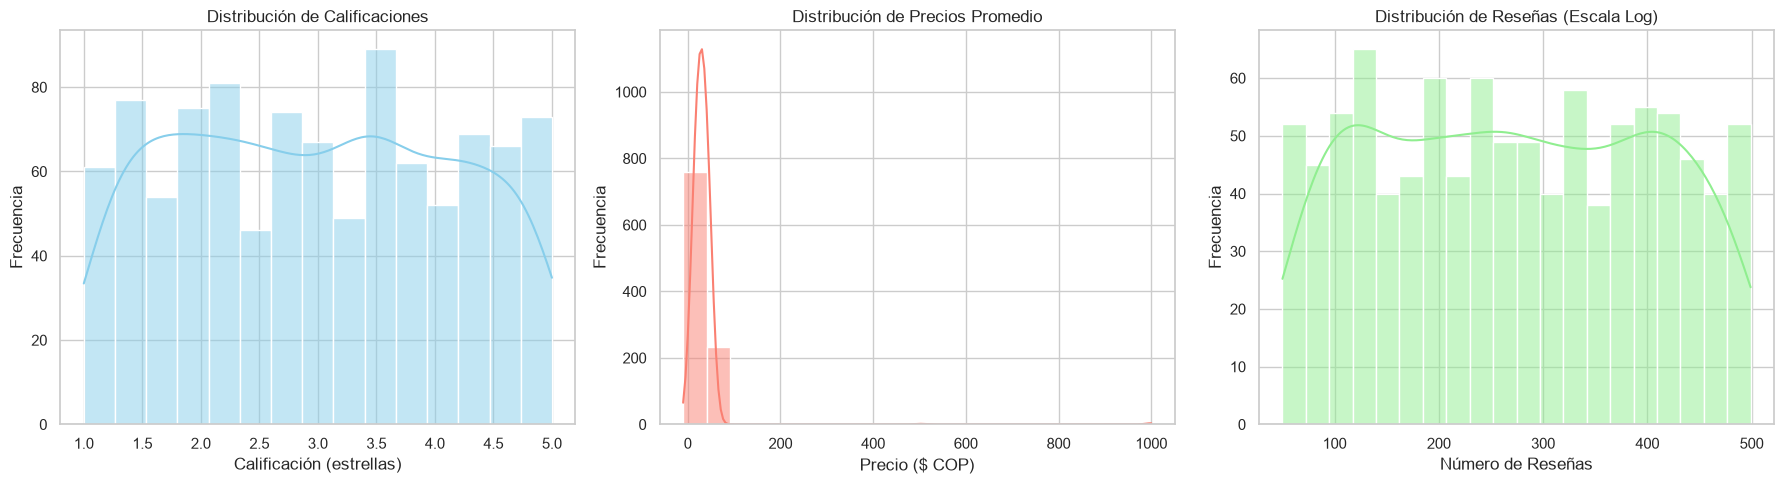

In [26]:
# ==============================================================================
# 4. VISUALIZACIONES CON MATPLOTLIB Y SEABORN
# ==============================================================================
print("\n--- 4. GENERANDO VISUALIZACIONES ---")

# Crear una figura compuesta (3 subgráficos en una fila para las distribuciones)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribución de Calificaciones
sns.histplot(df_clean['Calificación'], bins=15, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Calificaciones')
axes[0].set_xlabel('Calificación (estrellas)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Distribución de Precios Promedio
sns.histplot(df_clean['Precio promedio (USD)'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precios Promedio')
axes[1].set_xlabel('Precio ($ COP)')
axes[1].set_ylabel('Frecuencia')

# Gráfico 3: Distribución de Número de Reseñas (Escala logarítmica por la alta dispersión)
sns.histplot(df_clean['Número de reseñas'], bins=20, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Distribución de Reseñas (Escala Log)')
axes[2].set_xlabel('Número de Reseñas')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()